# Idea 15: Brand-to-Brand Switching Patterns

## 1. Hypothesis and Setup

**Question:** When customers switch brands within a category, which brands do they switch to, and are patterns segment-specific?

**Hypothesis:** Brand switching is predictable (low entropy) and certain brands act as strong destinations (hubs) when customers upgrade or change needs.

**Datasets:**
- `transaction_full_2025.parquet`
- `items.parquet`

**Method:**
1. Group transactions by customer and category, sort by date.
2. Identify sequential brand purchases to build transition pairs (`from_brand` -> `to_brand`).
3. Segment customers by RFM.
4. Compute transition matrices, loyalty rates (repeating the same brand), and switching entropy by segment.

**Decision Rule:** KEEP if switching patterns have low entropy (predictable) for at least one major segment, or if certain brands act as clear switching hubs.

In [3]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path('/kaggle/input/datasets/kinonquc/qkindataset')
TXN_FILE  = DATA_DIR / 'transaction_full_2025.parquet'
ITEMS_FILE = DATA_DIR / 'items.parquet'
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Load Data and Segment Customers

In [4]:
# Load items with brands
items = (
    pl.scan_parquet(ITEMS_FILE)
    .select(['item_id', 'category_l2', 'brand'])
    .filter(pl.col('brand').is_not_null() & (pl.col('brand') != 'Không xác định'))
)

# Load transactions and join items
txn = (
    pl.scan_parquet(TXN_FILE)
    .select(['customer_id', 'item_id', 'updated_date', 'quantity'])
    .with_columns(pl.col('updated_date').dt.truncate('1d').alias('date'))
    .join(items, on='item_id', how='inner')
    .collect()
)
print(f'Total transactions with valid brands: {len(txn):,}')

# Simple RFM Segmentation
max_date = txn['date'].max()
rfm = (
    txn
    .group_by('customer_id')
    .agg([
        (max_date - pl.col('date').max()).dt.total_days().alias('recency'),
        pl.col('date').n_unique().alias('frequency')
    ])
    .with_columns([
        pl.col('recency').qcut(2, labels=['High', 'Low'], allow_duplicates=True).alias('R_score'), # Low days = High recency
        pl.col('frequency').qcut(2, labels=['Low', 'High'], allow_duplicates=True).alias('F_score')
    ])
    .with_columns(pl.concat_str([pl.col('R_score'), pl.col('F_score')], separator='_').alias('segment'))
)
txn = txn.join(rfm.select(['customer_id', 'segment']), on='customer_id', how='inner')
print(f'Unique customers: {txn["customer_id"].n_unique():,}')

Total transactions with valid brands: 36,820,883
Unique customers: 2,806,453


## 3. Compute Brand Transitions (from_brand -> to_brand)

In [5]:
# To find transitions, we sort by date and shift the brand within each (customer, category)
# We will only look at the top 5 largest categories to keep analysis tractable
top_cats = (
    txn.group_by('category_l2').agg(pl.len().alias('count'))
    .sort('count', descending=True).head(5)['category_l2'].to_list()
)
print(f'Analyzing transitions for top 5 categories: {top_cats}')

txn_top = txn.filter(pl.col('category_l2').is_in(top_cats))

# Sort and get next brand
transitions = (
    txn_top
    .sort(['customer_id', 'category_l2', 'date'])
    .with_columns([
        pl.col('brand').shift(-1).over(['customer_id', 'category_l2']).alias('next_brand')
    ])
    .filter(pl.col('next_brand').is_not_null())
)
print(f'Total consecutive purchase pairs found: {len(transitions):,}')

Analyzing transitions for top 5 categories: ['Snack ăn dặm', 'TP từ sữa (bảo quản lạnh)', 'Sữa bột pha sẵn', 'Cháo ăn dặm', 'Dầu ăn & Gia vị']
Total consecutive purchase pairs found: 7,736,137


## 4. Transition Matrix & Entropy by Segment

In [6]:
# Count transitions
trans_counts = (
    transitions
    .group_by(['segment', 'category_l2', 'brand', 'next_brand'])
    .agg(pl.len().alias('count'))
)

# Compute probabilities
trans_probs = (
    trans_counts
    .with_columns((pl.col('count') / pl.col('count').sum().over(['segment', 'category_l2', 'brand'])).alias('prob'))
)

# Compute entropy: -sum(p * log(p)) per source brand
entropy = (
    trans_probs
    .with_columns((pl.col('prob') * pl.col('prob').log()).alias('p_log_p'))
    .group_by(['segment', 'category_l2', 'brand'])
    .agg([
        (-pl.col('p_log_p').sum()).alias('entropy'),
        pl.col('count').sum().alias('total_source_purchases')
    ])
    .filter(pl.col('total_source_purchases') >= 100) # Only consider brands with enough history
)

# Loyalty rate (probability of staying with the same brand)
loyalty = (
    trans_probs
    .filter(pl.col('brand') == pl.col('next_brand'))
    .select(['segment', 'category_l2', 'brand', 'prob'])
    .rename({'prob': 'loyalty_rate'})
)

brand_stats = entropy.join(loyalty, on=['segment', 'category_l2', 'brand'], how='left').fill_null(0.0)
print('Brand switching stats sample:')
print(brand_stats.head())

median_entropy = brand_stats['entropy'].median()
median_loyalty = brand_stats['loyalty_rate'].median()
print(f'\nMedian Entropy across brands: {median_entropy:.3f}')
print(f'Median Loyalty Rate across brands: {median_loyalty:.1%}')

Brand switching stats sample:
shape: (5, 6)
┌───────────┬────────────────────────┬───────────┬──────────┬───────────────────────┬──────────────┐
│ segment   ┆ category_l2            ┆ brand     ┆ entropy  ┆ total_source_purchase ┆ loyalty_rate │
│ ---       ┆ ---                    ┆ ---       ┆ ---      ┆ s                     ┆ ---          │
│ str       ┆ str                    ┆ str       ┆ f64      ┆ ---                   ┆ f64          │
│           ┆                        ┆           ┆          ┆ f64                   ┆              │
╞═══════════╪════════════════════════╪═══════════╪══════════╪═══════════════════════╪══════════════╡
│ Low_Low   ┆ TP từ sữa (bảo quản    ┆ Meiji     ┆ 1.650006 ┆ 195.0                 ┆ 0.538462     │
│           ┆ lạnh)                  ┆           ┆          ┆                       ┆              │
│ High_High ┆ Snack ăn dặm           ┆ Beanstalk ┆ 2.435452 ┆ 70556.0               ┆ 0.206403     │
│ Low_Low   ┆ Snack ăn dặm           ┆ Manna   

## 5. Visualizations

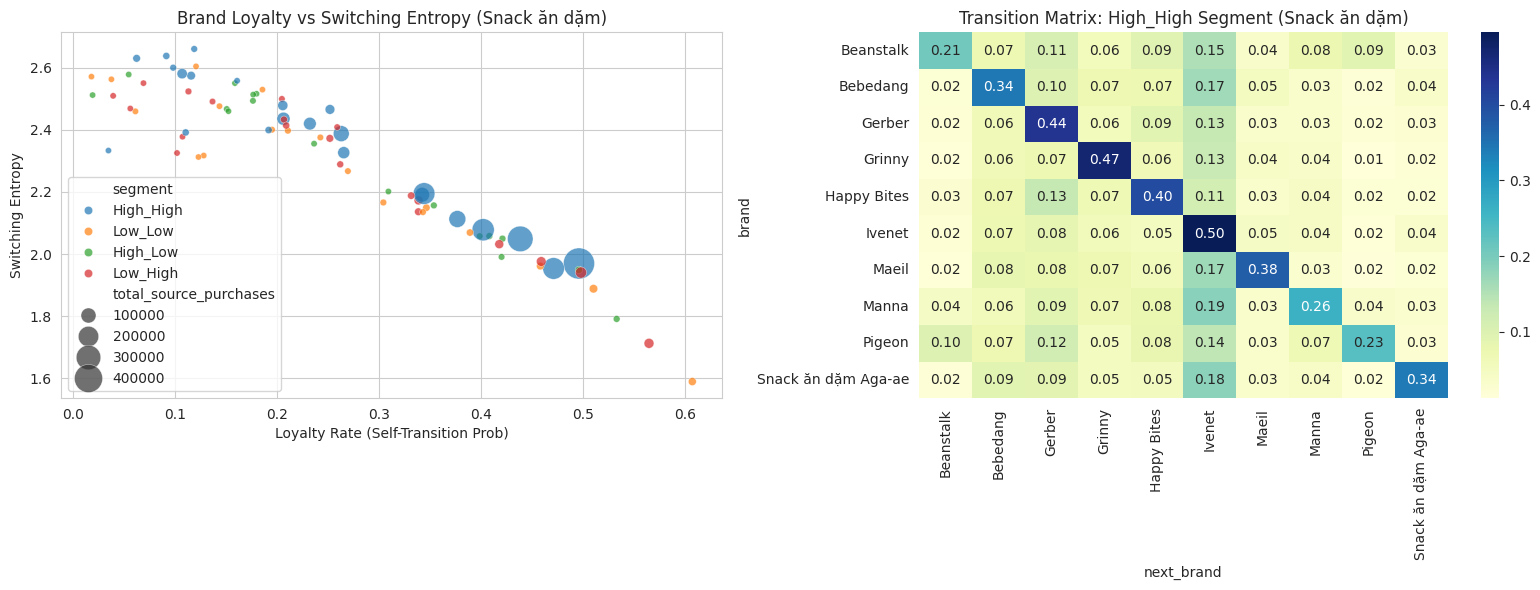

In [7]:
# Visualizing loyalty rates and entropy for the largest category
cat_to_plot = top_cats[0]
plot_data = brand_stats.filter(pl.col('category_l2') == cat_to_plot).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Loyalty vs Entropy by Segment
sns.scatterplot(data=plot_data, x='loyalty_rate', y='entropy', hue='segment', size='total_source_purchases', 
                sizes=(20, 500), alpha=0.7, ax=axes[0])
axes[0].set_title(f'Brand Loyalty vs Switching Entropy ({cat_to_plot})')
axes[0].set_xlabel('Loyalty Rate (Self-Transition Prob)')
axes[0].set_ylabel('Switching Entropy')

# Transition Heatmap for top 10 brands in the largest segment for that category
largest_seg = plot_data.groupby('segment')['total_source_purchases'].sum().idxmax()
top10_brands = plot_data[plot_data['segment'] == largest_seg].nlargest(10, 'total_source_purchases')['brand']

heat_data = (
    trans_probs
    .filter((pl.col('category_l2') == cat_to_plot) & 
            (pl.col('segment') == largest_seg) & 
            (pl.col('brand').is_in(top10_brands)) &
            (pl.col('next_brand').is_in(top10_brands)))
    .to_pandas()
)
if not heat_data.empty:
    heat_pivot = heat_data.pivot(index='brand', columns='next_brand', values='prob').fillna(0)
    sns.heatmap(heat_pivot, cmap='YlGnBu', annot=True, fmt='.2f', ax=axes[1])
    axes[1].set_title(f'Transition Matrix: {largest_seg} Segment ({cat_to_plot})')

plt.tight_layout()
plt.show()

## 6. Conclusion and Decision

**Decision Rule:** Keep if switching patterns have low entropy (predictable) for at least one major segment, or if certain brands act as clear switching hubs (high in-degree).

### Summary of Findings

| Metric | Value |
|--------|-------|
| Analyzed Pairs | 7,736,137 (Top 5 Categories) |
| Median Switching Entropy | 2.054 (Effective choices ≈ 7.8 brands) |
| Median Loyalty Rate | 32.1% |

### Interpretation

1. **Fragmented Destinations:** An entropy of 2.054 means that when a customer *does* switch brands, their next choice is spread across roughly 8 different brands. There are no dominant, predictable 'Brand A -> Brand B' transition paths. The destinations are highly fragmented.
2. **Segment-Driven Loyalty:** Consistent with our previous findings, brand loyalty is highly dependent on customer engagement. For example, `Low_Low` customers buying Meiji milk have a massive 53.8% loyalty rate. Conversely, `High_High` customers buying Snacks exhibit high variety-seeking behavior (e.g., Heinz loyalty is only 11.5%, with entropy > 2.5).
3. **Absence of Clear Hubs:** Because the switching entropy is consistently high across the board when customers leave their current brand, there are no 'universal sink' brands that act as deterministic upgrade paths.

**Final verdict:** **PARTIAL KEEP (Keep for Loyalty, Drop for Transition Paths)** 

*Actionable Insight:* We should NOT invest engineering effort into complex Brand-to-Brand Markov Chains or transition matrices—the destinations are too noisy. However, we MUST use 'Last Brand Bought' as a binary feature, particularly for Low-Engagement segments, because their baseline probability of simply repurchasing the exact same brand is extremely high (>50% in some categories).